# ЦФА vs Облигации: Сравнительный анализ

**Курс:** Блокчейн. Финансовые технологии и криптоэкономика  
**Задание:** Сравнить доходность ЦФА с облигациями эмитента на первичном рынке

---

## 📋 Цели анализа:

1. Сравнить доходность ЦФА и облигаций одного эмитента
2. Объяснить наблюдаемый спред
3. Оценить риски и доходность с учетом ликвидности
4. Дать инвестиционные рекомендации

## 📦 1. Импорт библиотек и настройка

In [2]:
# Импорт стандартных библиотек
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Настройка отображения графиков в ноутбуке
%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10
sns.set_style("whitegrid")

# Добавление src в path
sys.path.insert(0, os.path.join(os.path.dirname('__file__'), 'src'))

# Импорт модулей проекта
from src.config import DFA_PARAMS, BONDS_FILTER, ANALYSIS_CONFIG, VIZ_CONFIG
from src.dfa_analyzer import DFAAnalyzer
from src.bonds_analyzer import BondsAnalyzer
from src.comparator import DFAvsBondsComparator
from src.data_fetcher import create_sample_bonds_data

print("✓ Все библиотеки успешно импортированы")
print(f"✓ Путь к src добавлен")
print(f"✓ Дата анализа: {datetime.now().strftime('%Y-%m-%d')}")

✓ Все библиотеки успешно импортированы
✓ Путь к src добавлен
✓ Дата анализа: 2026-04-24


## 📊 2. Параметры ЦФА для анализа

In [3]:
# Вывод параметров ЦФА
print("=" * 70)
print("ПАРАМЕТРЫ ЦФА (ЦИФРОВОЙ ФИНАНСОВЫЙ АКТИВ)")
print("=" * 70)

print(f"\n📌 Идентификатор: {DFA_PARAMS['id']}")
print(f"🏢 Эмитент: {DFA_PARAMS['issuer']}")
print(f"🌐 Сайт: {DFA_PARAMS['website']}")

print(f"\n💰 Финансовые параметры:")
print(f"   • Номинал: {DFA_PARAMS['face_value']:,.2f} ₽")
print(f"   • Цена размещения: {DFA_PARAMS['placement_price']:,.2f} ₽")
print(f"   • Доходность: {DFA_PARAMS['yield_rate']}% годовых")
print(f"   • Тип купона: {DFA_PARAMS['coupon_type']}")
print(f"   • Периодичность: {DFA_PARAMS['coupon_frequency']}")

print(f"\n📅 Сроки:")
print(f"   • Размещение: {DFA_PARAMS['placement_start']} - {DFA_PARAMS['placement_end']}")
print(f"   • Погашение: {DFA_PARAMS['maturity_date']}")

print(f"\n📈 Объем выпуска:")
print(f"   • Общий объем: {DFA_PARAMS['issue_volume']:,.0f} ₽")
print(f"   • Мин. инвестиция: {DFA_PARAMS['min_investment']:,.0f} ₽")
print(f"   • Инвесторов: {DFA_PARAMS['investors_count']}")

print(f"\n⚠️ Обеспечение: {DFA_PARAMS['collateral']}")
print(f"🎯 Цель: {DFA_PARAMS['purpose']}")
print("\n" + "=" * 70)

ПАРАМЕТРЫ ЦФА (ЦИФРОВОЙ ФИНАНСОВЫЙ АКТИВ)

📌 Идентификатор: A1202FB5
🏢 Эмитент: ООО 'ЦЕНТР НЕДВИЖИМОСТИ 'МАЯК'
🌐 Сайт: https://new.ural-mayak.ru

💰 Финансовые параметры:
   • Номинал: 1,000.00 ₽
   • Цена размещения: 1,000.00 ₽
   • Доходность: 17.0% годовых
   • Тип купона: fixed
   • Периодичность: quarterly

📅 Сроки:
   • Размещение: 2026-04-14 - 2026-04-30
   • Погашение: 2027-05-03

📈 Объем выпуска:
   • Общий объем: 50,000,000 ₽
   • Мин. инвестиция: 1,000 ₽
   • Инвесторов: 73

⚠️ Обеспечение: без обеспечения
🎯 Цель: пополнение оборотных средств



## 🔍 3. Анализ ЦФА

In [4]:
# Инициализация анализатора ЦФА
dfa = DFAAnalyzer()

# Получение сводки анализа
dfa_summary = dfa.get_dfa_summary()

print("\n📊 РЕЗУЛЬТАТЫ АНАЛИЗА ЦФА")
print("-" * 50)

# Временные параметры
time_metrics = dfa_summary['time_metrics']
print(f"\n⏰ Временные параметры:")
print(f"   Срок обращения: {time_metrics['years_to_maturity']:.2f} лет")
print(f"   Дней до погашения: {time_metrics['days_to_maturity']}")

# Показатели доходности
yield_metrics = dfa_summary['yield_metrics']
print(f"\n💵 Доходность:")
print(f"   Номинальная: {yield_metrics['nominal_yield_pct']:.2f}%")
print(f"   После налога: {yield_metrics['after_tax_yield_pct']:.2f}%")
print(f"   С учетом ликвидности: {yield_metrics['liquidity_adjusted_yield_pct']:.2f}%")

# Показатели возврата
return_metrics = dfa_summary['return_metrics']
print(f"\n📈 Показатели возврата:")
print(f"   Купонный доход: {return_metrics['total_coupon']:,.2f} ₽")
print(f"   Общий доход: {return_metrics['total_return_pct']:.2f}%")
print(f"   Годовая доходность: {return_metrics['annualized_return']:.2f}%")

# Рисковые метрики
risk_metrics = dfa_summary['risk_metrics']
print(f"\n⚠️ Рисковые метрики:")
print(f"   Премия за риск: {risk_metrics['risk_premium']:.2f}%")
print(f"   Коэффициент Шарпа: {risk_metrics['sharpe_ratio']:.3f}")
print(f"   Бета-коэффициент: {risk_metrics['beta']:.2f}")


📊 РЕЗУЛЬТАТЫ АНАЛИЗА ЦФА
--------------------------------------------------

⏰ Временные параметры:
   Срок обращения: 1.05 лет
   Дней до погашения: 384

💵 Доходность:
   Номинальная: 17.00%
   После налога: 14.79%
   С учетом ликвидности: 17.00%

📈 Показатели возврата:
   Купонный доход: 170.00 ₽
   Общий доход: 17.00%
   Годовая доходность: 16.17%

⚠️ Рисковые метрики:
   Премия за риск: 5.00%
   Коэффициент Шарпа: 0.333
   Бета-коэффициент: 1.20


## 💳 4. График купонных платежей ЦФА

/var/folders/jm/f922w7sx4w95q3w5xgq58fm40000gn/T/ipykernel_3549/1543748346.py:40: UserWarning: Glyph 8381 (\N{RUBLE SIGN}) missing from font(s) Arial.
  plt.tight_layout()
/Users/diana/repos/fin-tech_da/blockchain/venv/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Glyph 8381 (\N{RUBLE SIGN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


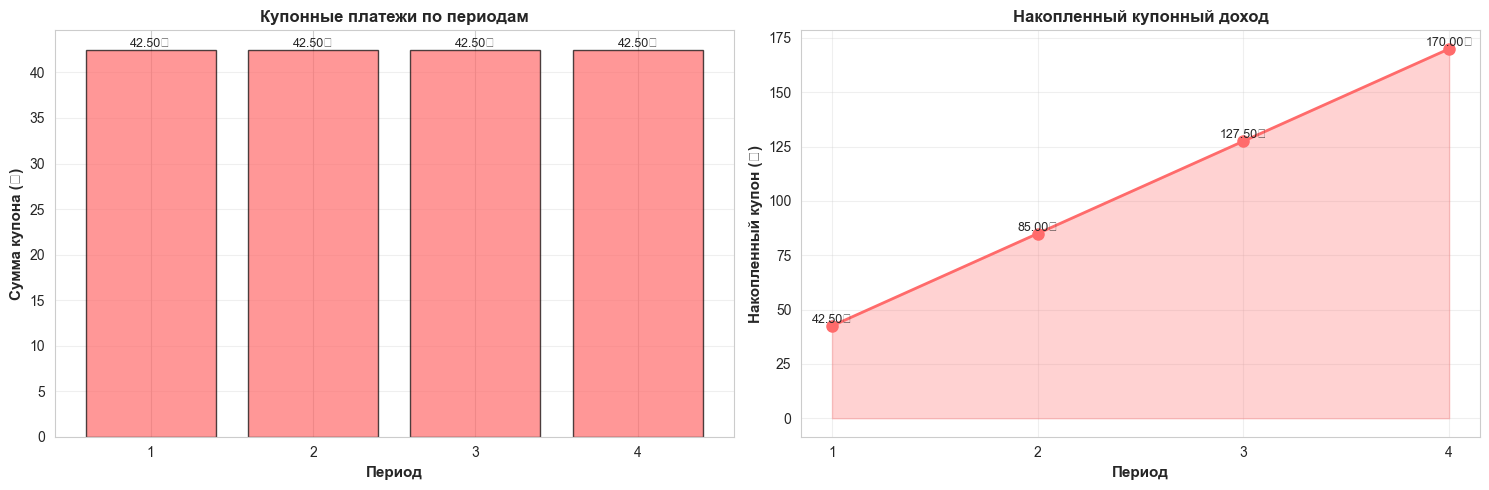


📅 ГРАФИК КУПОННЫХ ПЛАТЕЖЕЙ:
 period payment_date  days_from_placement  coupon_amount  cumulative_coupon
      1   2026-07-19                   96           42.5               42.5
      2   2026-10-23                  192           42.5               85.0
      3   2027-01-27                  288           42.5              127.5
      4   2027-05-03                  384           42.5              170.0


In [5]:
# Получение графика купонных платежей
coupon_schedule = dfa.calculate_coupon_payments()

# Визуализация
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# График 1: Купонные платежи
ax1.bar(range(1, len(coupon_schedule)+1), 
        coupon_schedule['coupon_amount'], 
        color='#FF6B6B', alpha=0.7, edgecolor='black')
ax1.set_xlabel('Период', fontsize=11, fontweight='bold')
ax1.set_ylabel('Сумма купона (₽)', fontsize=11, fontweight='bold')
ax1.set_title('Купонные платежи по периодам', fontsize=12, fontweight='bold')
ax1.grid(axis='y', alpha=0.3)
ax1.set_xticks(range(1, len(coupon_schedule)+1))

# Добавление значений на бары
for i, coupon in enumerate(coupon_schedule['coupon_amount']):
    ax1.text(i+1, coupon, f'{coupon:.2f}₽', 
             ha='center', va='bottom', fontsize=9)

# График 2: Накопленный доход
ax2.plot(range(1, len(coupon_schedule)+1), 
         coupon_schedule['cumulative_coupon'], 
         marker='o', linewidth=2, markersize=8, color='#FF6B6B')
ax2.fill_between(range(1, len(coupon_schedule)+1), 
                  coupon_schedule['cumulative_coupon'], 
                  alpha=0.3, color='#FF6B6B')
ax2.set_xlabel('Период', fontsize=11, fontweight='bold')
ax2.set_ylabel('Накопленный купон (₽)', fontsize=11, fontweight='bold')
ax2.set_title('Накопленный купонный доход', fontsize=12, fontweight='bold')
ax2.grid(True, alpha=0.3)
ax2.set_xticks(range(1, len(coupon_schedule)+1))

# Добавление значений
for i, cum_coupon in enumerate(coupon_schedule['cumulative_coupon']):
    ax2.text(i+1, cum_coupon, f'{cum_coupon:.2f}₽', 
             ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Таблица с графиком платежей
print("\n📅 ГРАФИК КУПОННЫХ ПЛАТЕЖЕЙ:")
print(coupon_schedule.to_string(index=False))

## 🏦 5. Подбор сопоставимых облигаций

In [6]:
# Получение данных по облигациям
bonds_data = create_sample_bonds_data()

print("\n🔍 КРИТЕРИИ ОТБОРА ОБЛИГАЦИЙ:")
print("-" * 50)
print(f"Срок погашения: {BONDS_FILTER['maturity_min_months']}-{BONDS_FILTER['maturity_max_months']} месяцев")
print(f"Период размещения: {BONDS_FILTER['placement_month_min']} - {BONDS_FILTER['placement_month_max']}")
print(f"Мин. кредитный рейтинг: {BONDS_FILTER['min_credit_rating']}")
print(f"Объем выпуска: {BONDS_FILTER['min_issue_volume']:,.0f} - {BONDS_FILTER['max_issue_volume']:,.0f} ₽")

print(f"\n✓ Найдено сопоставимых облигаций: {len(bonds_data)}")

# Отображение таблицы облигаций
print("\n📊 СПИСОК СОПОСТАВИМЫХ ОБЛИГАЦИЙ:")
print("=" * 100)
print(bonds_data[['secid', 'name', 'coupon_rate', 'ytm_primary', 
                 'maturity_date', 'volume', 'credit_rating']].to_string(index=False))
print("=" * 100)


🔍 КРИТЕРИИ ОТБОРА ОБЛИГАЦИЙ:
--------------------------------------------------
Срок погашения: 10-14 месяцев
Период размещения: 2026-03 - 2026-05
Мин. кредитный рейтинг: B
Объем выпуска: 10,000,000 - 500,000,000 ₽

✓ Найдено сопоставимых облигаций: 4

📊 СПИСОК СОПОСТАВИМЫХ ОБЛИГАЦИЙ:
   secid                                   name  coupon_rate  ytm_primary maturity_date   volume credit_rating
 МаякБP1 БО-01 ООО 'ЦЕНТР НЕДВИЖИМОСТИ МАЯК' P1         16.5        16.65    2027-05-15 30000000            B+
 МаякБP2 БО-02 ООО 'ЦЕНТР НЕДВИЖИМОСТИ МАЯК' P2         17.0        17.00    2027-04-20 40000000            B+
 RUСтрA1                     БО-001 РУССТРОЙ АО         18.0        18.50    2027-06-01 50000000             B
UralDev1                 БО-001 УРАЛДЕВЕЛОПМЕНТ         16.0        15.90    2027-04-01 35000000           BB-


## 📈 6. Анализ облигаций

In [7]:
# Инициализация анализатора облигаций
bonds_analyzer = BondsAnalyzer(bonds_data)
bonds_analysis = bonds_analyzer.analyze_all_bonds()
bonds_summary = bonds_analyzer.get_summary_statistics(bonds_analysis)

print("\n📊 СТАТИСТИКА ПО ВЫБОРКЕ ОБЛИГАЦИЙ")
print("-" * 50)

# Доходность
yield_stats = bonds_summary['yield_stats']
print(f"\n💵 Доходность (YTM):")
print(f"   Средняя: {yield_stats['mean_ytm']:.2f}%")
print(f"   Медиана: {yield_stats['median_ytm']:.2f}%")
print(f"   Стд. отклонение: {yield_stats['std_ytm']:.2f}%")
print(f"   Диапазон: {yield_stats['min_ytm']:.2f}% - {yield_stats['max_ytm']:.2f}%")

# После налога
after_tax_stats = bonds_summary['after_tax_stats']
print(f"\n💰 После налога:")
print(f"   Средняя: {after_tax_stats['mean_after_tax']:.2f}%")
print(f"   Медиана: {after_tax_stats['median_after_tax']:.2f}%")

# Рисковые метрики
risk_stats = bonds_summary['risk_stats']
print(f"\n⚠️ Рисковые метрики:")
print(f"   Премия за риск: {risk_stats['mean_risk_premium']:.2f}%")
print(f"   Средний Sharpe: {risk_stats['mean_sharpe']:.3f}")

# Объем
volume_stats = bonds_summary['volume_stats']
print(f"\n📊 Объем выпусков:")
print(f"   Общий: {volume_stats['total_volume']:,.0f} ₽")
print(f"   Средний: {volume_stats['mean_volume']:,.0f} ₽")


📊 СТАТИСТИКА ПО ВЫБОРКЕ ОБЛИГАЦИЙ
--------------------------------------------------

💵 Доходность (YTM):
   Средняя: 17.01%
   Медиана: 16.82%
   Стд. отклонение: 1.09%
   Диапазон: 15.90% - 18.50%

💰 После налога:
   Средняя: 14.81%
   Медиана: 14.64%

⚠️ Рисковые метрики:
   Премия за риск: 5.01%
   Средний Sharpe: 0.418

📊 Объем выпусков:
   Общий: 155,000,000 ₽
   Средний: 38,750,000 ₽


## 📊 7. Детальный анализ облигаций

In [8]:
# Создание красивой таблицы с анализом
display_cols = ['secid', 'coupon_rate', 'ytm_primary', 'after_tax_yield', 
               'liquidity_score', 'sharpe_ratio', 'credit_rating']

analysis_display = bonds_analysis[display_cols].copy()
analysis_display.columns = ['Облигация', 'Купон %', 'YTM %', 'После налога %', 
                             'Ликвидность', 'Sharpe', 'Рейтинг']

print("\n📋 ДЕТАЛЬНЫЙ АНАЛИЗ ОБЛИГАЦИЙ:")
print("=" * 100)
print(analysis_display.to_string(index=False))
print("=" * 100)


📋 ДЕТАЛЬНЫЙ АНАЛИЗ ОБЛИГАЦИЙ:
Облигация  Купон %  YTM %  После налога %  Ликвидность   Sharpe Рейтинг
  МаякБP1     16.5  16.65       14.496372         0.70 0.387500      B+
  МаякБP2     17.0  17.00       14.790000         0.80 0.416667      B+
  RUСтрA1     18.0  18.50       16.135338         0.60 0.541667       B
 UralDev1     16.0  15.90       13.826087         0.75 0.325000     BB-


## ⚖️ 8. Сравнительный анализ: ЦФА vs Облигации

In [9]:
# Инициализация компаратора
comparator = DFAvsBondsComparator(dfa, bonds_analyzer)

# Первичное сравнение
primary_comparison = comparator.compare_primary_market_yields()

print("\n⚖️ СРАВНЕНИЕ ДОХОДНОСТИ НА ПЕРВИЧНОМ РЫНКЕ")
print("=" * 80)

for _, row in primary_comparison.iterrows():
    print(f"\n{row['bond_secid']}:")
    print(f"   ЦФА: {row['dfa_yield']:.2f}%")
    print(f"   Облигация: {row['bond_yield']:.2f}%")
    print(f"   Спред: {row['absolute_spread_pct']:+.2f}% (ЦФА {'выше' if row['absolute_spread_pct'] > 0 else 'ниже'})")
    if row['is_significant']:
        print(f"   ⚠️ Значимый спред!")

print("\n" + "=" * 80)
print(f"\n📊 СРЕДНИЙ СПРЕД: {primary_comparison['absolute_spread_pct'].mean():+.2f}%")
print(f"Значимых спредов: {primary_comparison['is_significant'].sum()} из {len(primary_comparison)}")


⚖️ СРАВНЕНИЕ ДОХОДНОСТИ НА ПЕРВИЧНОМ РЫНКЕ

МаякБP1:
   ЦФА: 17.00%
   Облигация: 16.65%
   Спред: +0.35% (ЦФА выше)

МаякБP2:
   ЦФА: 17.00%
   Облигация: 17.00%
   Спред: +0.00% (ЦФА ниже)

RUСтрA1:
   ЦФА: 17.00%
   Облигация: 18.50%
   Спред: -1.50% (ЦФА ниже)

UralDev1:
   ЦФА: 17.00%
   Облигация: 15.90%
   Спред: +1.10% (ЦФА выше)


📊 СРЕДНИЙ СПРЕД: -0.01%
Значимых спредов: 0 из 4


## 📉 9. График сравнения доходности

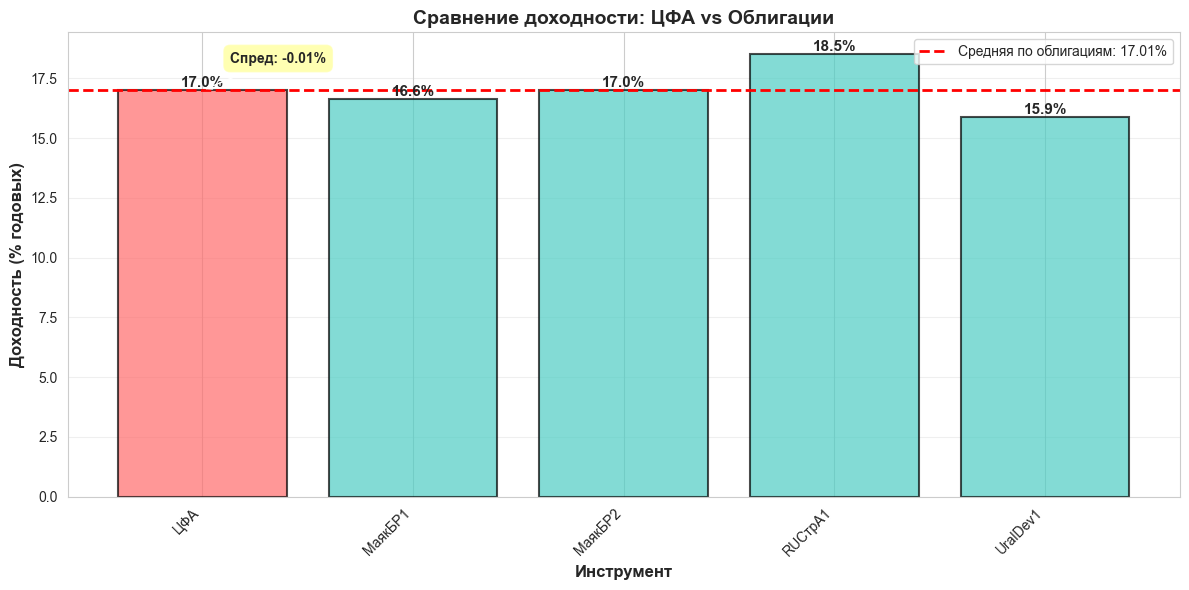


📊 ВЫВОД:
ЦФА предлагает доходность НИЖЕ средней по облигациям на 0.01%


In [10]:
# Визуализация сравнения доходности
fig, ax = plt.subplots(figsize=(12, 6))

# Подготовка данных
instruments = ['ЦФА'] + bonds_analysis['secid'].tolist()
yields = [dfa_summary['yield_metrics']['nominal_yield_pct']] + bonds_analysis['ytm_primary'].tolist()
colors = ['#FF6B6B'] + ['#4ECDC4'] * len(bonds_analysis)

# Создание bar chart
bars = ax.bar(range(len(instruments)), yields, color=colors, 
              alpha=0.7, edgecolor='black', linewidth=1.5)

# Добавление линии средней доходности облигаций
avg_bond_yield = bonds_analysis['ytm_primary'].mean()
ax.axhline(y=avg_bond_yield, color='red', linestyle='--', 
          linewidth=2, label=f'Средняя по облигациям: {avg_bond_yield:.2f}%')

# Добавление значений
for bar, yield_val in zip(bars, yields):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
           f'{yield_val:.1f}%',
           ha='center', va='bottom', fontsize=11, fontweight='bold')

# Настройка графика
ax.set_xlabel('Инструмент', fontsize=12, fontweight='bold')
ax.set_ylabel('Доходность (% годовых)', fontsize=12, fontweight='bold')
ax.set_title('Сравнение доходности: ЦФА vs Облигации', fontsize=14, fontweight='bold')
ax.set_xticks(range(len(instruments)))
ax.set_xticklabels(instruments, rotation=45, ha='right')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

# Добавление аннотации о спреде
dfa_yield = dfa_summary['yield_metrics']['nominal_yield_pct']
spread = dfa_yield - avg_bond_yield
ax.annotate(f'Спред: {spread:+.2f}%',
            xy=(0, dfa_yield),
            xytext=(20, 20), textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.3),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'),
            fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 ВЫВОД:")
if spread > 0:
    print(f"ЦФА предлагает доходность ВЫШЕ средней по облигациям на {spread:.2f}%")
else:
    print(f"ЦФА предлагает доходность НИЖЕ средней по облигациям на {abs(spread):.2f}%")

## 📊 10. График анализа спреда

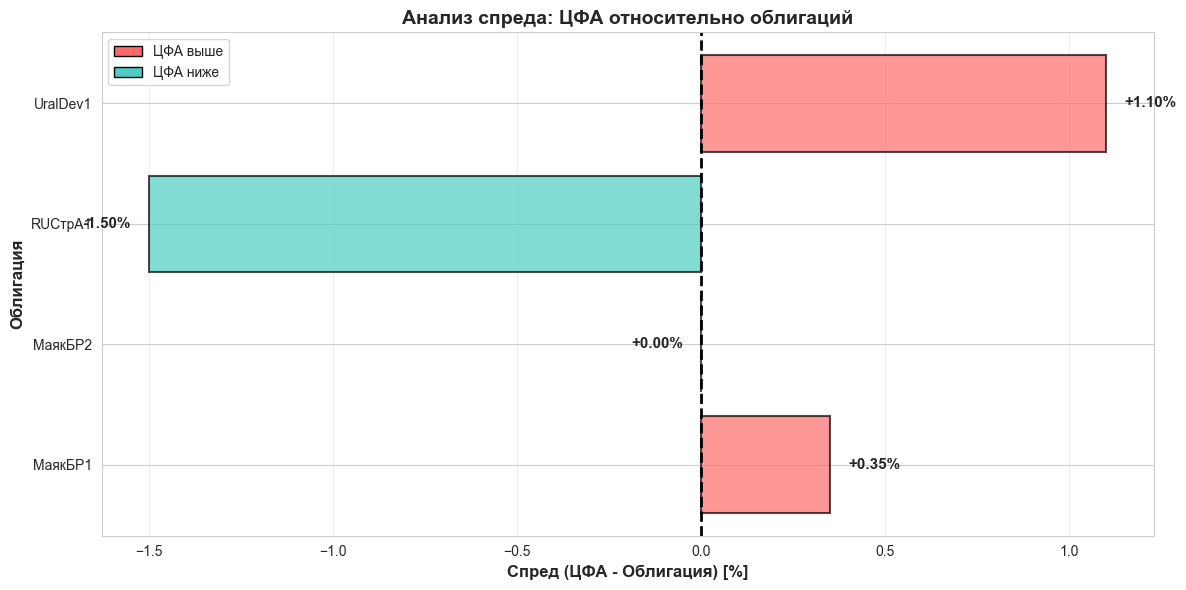


📊 АНАЛИЗ СПРЕДА:
Минимальный спред: -1.50%
Максимальный спред: +1.10%
Средний спред: -0.01%
Стд. отклонение: 0.95%


In [11]:
# Визуализация спреда
fig, ax = plt.subplots(figsize=(12, 6))

spreads = primary_comparison['absolute_spread_pct'].tolist()
bond_names = primary_comparison['bond_secid'].tolist()

# Цвета в зависимости от знака спреда
colors = ['#FF6B6B' if s > 0 else '#4ECDC4' for s in spreads]

# Горизонтальный bar chart
bars = ax.barh(range(len(spreads)), spreads, color=colors, 
              alpha=0.7, edgecolor='black', linewidth=1.5)

# Вертикальная линия на нуле
ax.axvline(x=0, color='black', linestyle='--', linewidth=2)

# Добавление значений
for bar, spread in zip(bars, spreads):
    width = bar.get_width()
    ax.text(width + (0.05 if width > 0 else -0.05), 
           bar.get_y() + bar.get_height()/2,
           f'{spread:+.2f}%',
           ha='left' if width > 0 else 'right', 
           va='center', fontsize=11, fontweight='bold')

# Настройка
ax.set_xlabel('Спред (ЦФА - Облигация) [%]', fontsize=12, fontweight='bold')
ax.set_ylabel('Облигация', fontsize=12, fontweight='bold')
ax.set_title('Анализ спреда: ЦФА относительно облигаций', fontsize=14, fontweight='bold')
ax.set_yticks(range(len(bond_names)))
ax.set_yticklabels(bond_names)
ax.grid(axis='x', alpha=0.3)

# Легенда
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#FF6B6B', edgecolor='black', label='ЦФА выше'),
                  Patch(facecolor='#4ECDC4', edgecolor='black', label='ЦФА ниже')]
ax.legend(handles=legend_elements, loc='best', fontsize=10)

plt.tight_layout()
plt.show()

print("\n📊 АНАЛИЗ СПРЕДА:")
print(f"Минимальный спред: {min(spreads):+.2f}%")
print(f"Максимальный спред: {max(spreads):+.2f}%")
print(f"Средний спред: {np.mean(spreads):+.2f}%")
print(f"Стд. отклонение: {np.std(spreads):.2f}%")

## ⚡ 11. Профиль риск-доходность

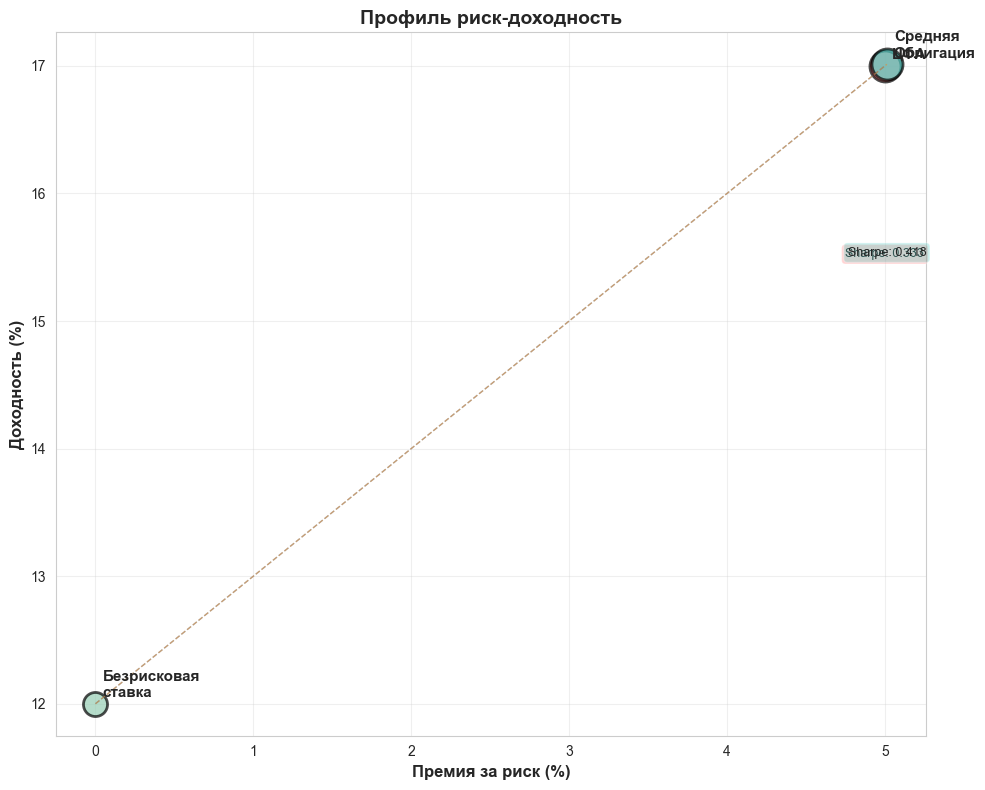


⚡ ПРОФИЛЬ РИСК-ДОХОДНОСТЬ:

ЦФА:
  Доходность: 17.00%
  Риск: 5.00%
  Sharpe: 0.333

Облигации (средние):
  Доходность: 17.01%
  Риск: 5.01%
  Sharpe: 0.418

✅ Облигации показывают лучшую эффективность по Sharpe


In [12]:
# Получение данных риск-доходность
risk_return_profile = comparator.analyze_risk_return_profile()

# Визуализация
fig, ax = plt.subplots(figsize=(10, 8))

# Данные
instruments = ['ЦФА', 'Средняя\nОблигация', 'Безрисковая\nставка']
returns = [
    dfa_summary['yield_metrics']['nominal_yield_pct'],
    bonds_summary['yield_stats']['mean_ytm'],
    ANALYSIS_CONFIG['risk_free_rate']
]
risks = [
    dfa_summary['risk_metrics']['risk_premium'],
    bonds_summary['risk_stats']['mean_risk_premium'],
    0
]
sizes = [500, 500, 300]
colors = ['#FF6B6B', '#4ECDC4', '#96CEB4']

# Scatter plot
for i, (instrument, ret, risk, size, color) in enumerate(zip(instruments, returns, risks, sizes, colors)):
    ax.scatter(risk, ret, s=size, alpha=0.7, color=color, 
               edgecolors='black', linewidth=2)
    ax.annotate(instrument, (risk, ret),
               xytext=(5, 5), textcoords='offset points',
               fontsize=11, fontweight='bold')

# Добавление линий от безрисковой ставки
for i in range(2):
    ax.plot([0, risks[i]], [ANALYSIS_CONFIG['risk_free_rate'], returns[i]],
            '--', alpha=0.5, linewidth=1)

# Настройка
ax.set_xlabel('Премия за риск (%)', fontsize=12, fontweight='bold')
ax.set_ylabel('Доходность (%)', fontsize=12, fontweight='bold')
ax.set_title('Профиль риск-доходность', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)

# Добавление аннотаций Sharpe ratio
dfa_sharpe = dfa_summary['risk_metrics']['sharpe_ratio']
bond_sharpe = bonds_summary['risk_stats']['mean_sharpe']

ax.text(risks[0], returns[0] - 1.5, f"Sharpe: {dfa_sharpe:.3f}",
       ha='center', fontsize=9, 
       bbox=dict(boxstyle='round,pad=0.3', facecolor='#FF6B6B', alpha=0.3))
ax.text(risks[1], returns[1] - 1.5, f"Sharpe: {bond_sharpe:.3f}",
       ha='center', fontsize=9,
       bbox=dict(boxstyle='round,pad=0.3', facecolor='#4ECDC4', alpha=0.3))

plt.tight_layout()
plt.show()

print("\n⚡ ПРОФИЛЬ РИСК-ДОХОДНОСТЬ:")
print(f"\nЦФА:")
print(f"  Доходность: {returns[0]:.2f}%")
print(f"  Риск: {risks[0]:.2f}%")
print(f"  Sharpe: {dfa_sharpe:.3f}")

print(f"\nОблигации (средние):")
print(f"  Доходность: {returns[1]:.2f}%")
print(f"  Риск: {risks[1]:.2f}%")
print(f"  Sharpe: {bond_sharpe:.3f}")

if dfa_sharpe > bond_sharpe:
    print("\n✅ ЦФА показывает лучшую эффективность по Sharpe")
else:
    print("\n✅ Облигации показывают лучшую эффективность по Sharpe")

## 🔍 12. Декомпозиция спреда


🔍 ДЕКОМПОЗИЦИЯ СПРЕДА НА ФАКТОРЫ:
🔴 Liquidity Component: +0.13%
🟢 Credit Component: +0.00%
🔴 Technology Component: +0.50%
🔴 Regulatory Component: +0.30%

📊 Необъясненный остаток: -0.94%


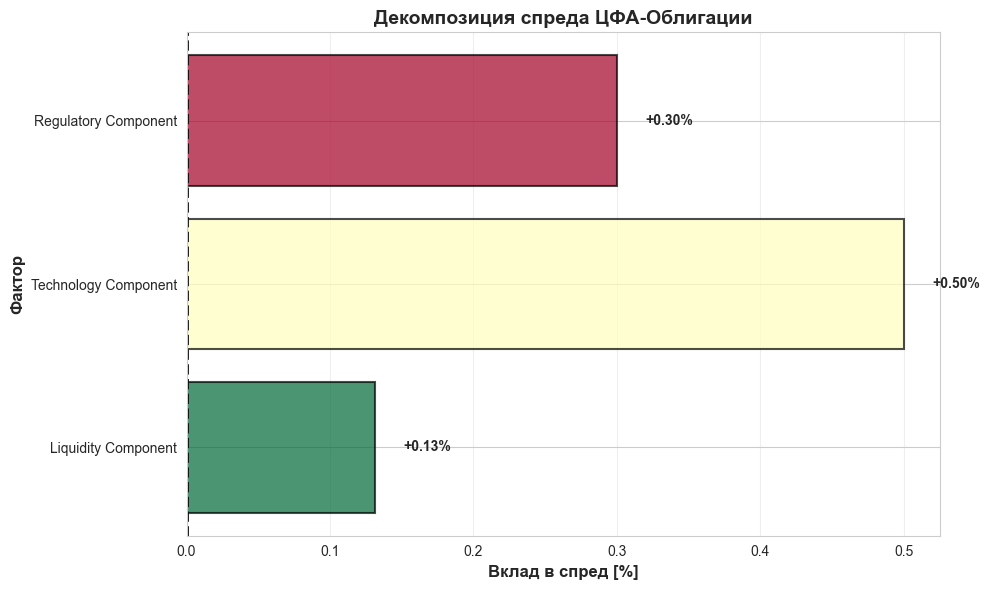

In [13]:
# Анализ факторов спреда
spread_drivers = comparator.identify_spread_drivers()

print("\n🔍 ДЕКОМПОЗИЦИЯ СПРЕДА НА ФАКТОРЫ:")
print("=" * 60)

for driver, value in spread_drivers.items():
    if driver not in ['total_spread', 'unexplained']:
        icon = "🔴" if value > 0 else "🟢"
        print(f"{icon} {driver.replace('_', ' ').title()}: {value:+.2f}%")

print(f"\n📊 Необъясненный остаток: {spread_drivers['unexplained']:+.2f}%")
print("=" * 60)

# Визуализация декомпозиции
fig, ax = plt.subplots(figsize=(10, 6))

# Подготовка данных (исключая total_spread и unexplained)
plot_drivers = {k: v for k, v in spread_drivers.items() 
                if k not in ['total_spread', 'unexplained'] and v != 0}

driver_names = [name.replace('_', ' ').title() for name in plot_drivers.keys()]
driver_values = list(plot_drivers.values())

if len(driver_values) > 0:
    colors = plt.cm.RdYlGn_r(np.linspace(0, 1, len(driver_values)))
    
    bars = ax.barh(range(len(driver_values)), driver_values,
                  color=colors, alpha=0.7, edgecolor='black', linewidth=1.5)
    
    # Вертикальная линия
    ax.axvline(x=0, color='black', linestyle='--', linewidth=2)
    
    # Значения
    for bar, value in zip(bars, driver_values):
        width = bar.get_width()
        ax.text(width + (0.02 if width > 0 else -0.02),
               bar.get_y() + bar.get_height()/2,
               f'{value:+.2f}%',
               ha='left' if width > 0 else 'right',
               va='center', fontsize=10, fontweight='bold')
    
    # Настройка
    ax.set_xlabel('Вклад в спред [%]', fontsize=12, fontweight='bold')
    ax.set_ylabel('Фактор', fontsize=12, fontweight='bold')
    ax.set_title('Декомпозиция спреда ЦФА-Облигации', fontsize=14, fontweight='bold')
    ax.set_yticks(range(len(driver_names)))
    ax.set_yticklabels(driver_names)
    ax.grid(axis='x', alpha=0.3)
    
    plt.tight_layout()
    plt.show()

## 🎯 13. Инвестиционные рекомендации

In [14]:
# Генерация рекомендаций
recommendation = comparator.generate_investment_recommendation()

print("\n" + "=" * 70)
print("🎯 ИНВЕСТИЦИОННЫЕ РЕКОМЕНДАЦИИ")
print("=" * 70)

print(f"\n📊 ОБЩАЯ РЕКОМЕНДАЦИЯ: {recommendation['overall_recommendation'].upper()}")
print(f"\nОбоснование: {recommendation['reasoning']}")

print(f"\n📈 КЛЮЧЕВЫЕ ФАКТОРЫ:")
key_factors = recommendation['key_factors']
print(f"  • Преимущество в доходности: {key_factors['yield_advantage']:+.2f}%")
print(f"  • Преимущество в Sharpe: {key_factors['sharpe_advantage']:+.3f}")
print(f"  • Дисконт за ликвидность: {key_factors['liquidity_disadvantage']:+.2f}%")

print(f"\n👤 РЕКОМЕНДАЦИИ ДЛЯ РАЗЛИЧНЫХ ИНВЕСТОРОВ:")
for profile, advice in recommendation['investor_suggestions'].items():
    print(f"\n  {profile.upper()} ИНВЕСТОР:")
    print(f"    Выбор: {advice['preferred']}")
    print(f"    Обоснование: {advice['reason']}")

print("\n" + "=" * 70)


🎯 ИНВЕСТИЦИОННЫЕ РЕКОМЕНДАЦИИ

📊 ОБЩАЯ РЕКОМЕНДАЦИЯ: BONDS

Обоснование: Bonds offer better risk-adjusted returns

📈 КЛЮЧЕВЫЕ ФАКТОРЫ:
  • Преимущество в доходности: -0.01%
  • Преимущество в Sharpe: -0.084
  • Дисконт за ликвидность: +0.13%

👤 РЕКОМЕНДАЦИИ ДЛЯ РАЗЛИЧНЫХ ИНВЕСТОРОВ:

  CONSERVATIVE ИНВЕСТОР:
    Выбор: Bonds
    Обоснование: Higher liquidity, established market, lower regulatory risk

  BALANCED ИНВЕСТОР:
    Выбор: Bonds
    Обоснование: Bonds offer better risk-adjusted returns

  AGGRESSIVE ИНВЕСТОР:
    Выбор: DFA
    Обоснование: Higher yield potential, diversification benefit



## 📊 14. Сводная таблица сравнения

In [15]:
# Создание сводной таблицы
summary_data = {
    'Показатель': [
        'Доходность номинальная (%)',
        'Доходность после налога (%)',
        'Срок обращения (мес)',
        'Премия за риск (%)',
        'Sharpe Ratio',
        'Мин. сумма инвестиции (₽)',
        'Ликвидность',
        'Риски'
    ],
    'ЦФА': [
        f"{dfa_summary['yield_metrics']['nominal_yield_pct']:.2f}",
        f"{dfa_summary['yield_metrics']['after_tax_yield_pct']:.2f}",
        f"{dfa_summary['time_metrics']['years_to_maturity']*12:.0f}",
        f"{dfa_summary['risk_metrics']['risk_premium']:.2f}",
        f"{dfa_summary['risk_metrics']['sharpe_ratio']:.3f}",
        f"{DFA_PARAMS['min_investment']:,.0f}",
        'Низкая',
        'Высокие (технология, регуляция)'
    ],
    'Облигации (средние)': [
        f"{bonds_summary['yield_stats']['mean_ytm']:.2f}",
        f"{bonds_summary['after_tax_stats']['mean_after_tax']:.2f}",
        '12',
        f"{bonds_summary['risk_stats']['mean_risk_premium']:.2f}",
        f"{bonds_summary['risk_stats']['mean_sharpe']:.3f}",
        '1,000 - 100,000',
        'Высокая',
        'Средние (кредитный, процентный)'
    ]
}

summary_df = pd.DataFrame(summary_data)

print("\n📊 СВОДНАЯ ТАБЛИЦА СРАВНЕНИЯ")
print("=" * 100)
print(summary_df.to_string(index=False))
print("=" * 100)


📊 СВОДНАЯ ТАБЛИЦА СРАВНЕНИЯ
                 Показатель                             ЦФА             Облигации (средние)
 Доходность номинальная (%)                           17.00                           17.01
Доходность после налога (%)                           14.79                           14.81
       Срок обращения (мес)                              13                              12
         Премия за риск (%)                            5.00                            5.01
               Sharpe Ratio                           0.333                           0.418
  Мин. сумма инвестиции (₽)                           1,000                 1,000 - 100,000
                Ликвидность                          Низкая                         Высокая
                      Риски Высокие (технология, регуляция) Средние (кредитный, процентный)


## ✅ 15. Заключение и выводы

In [16]:
print("\n" + "=" * 70)
print("✅ ЗАКЛЮЧЕНИЕ И ВЫВОДЫ")
print("=" * 70)

# Ключевые метрики
dfa_yield = dfa_summary['yield_metrics']['nominal_yield_pct']
avg_bond_yield = bonds_summary['yield_stats']['mean_ytm']
spread = dfa_yield - avg_bond_yield
dfa_sharpe = dfa_summary['risk_metrics']['sharpe_ratio']
avg_bond_sharpe = bonds_summary['risk_stats']['mean_sharpe']

print("\n📊 ОСНОВНЫЕ РЕЗУЛЬТАТЫ:")
print("-" * 50)

print(f"\n1. ДОХОДНОСТЬ:")
if abs(spread) < 0.5:
    print(f"   ✅ Спред минимальный ({spread:+.2f}%) - доходности сопоставимы")
elif spread > 0:
    print(f"   📈 ЦФА превосходит облигации на {spread:.2f}%")
else:
    print(f"   📉 Облигации превосходят ЦФА на {abs(spread):.2f}%")

print(f"\n2. ЭФФЕКТИВНОСТЬ (Sharpe Ratio):")
if dfa_sharpe > avg_bond_sharpe:
    print(f"   ✅ ЦФА: {dfa_sharpe:.3f} > Облигации: {avg_bond_sharpe:.3f}")
    print(f"   💡 Лучший риск-скорректированный доход")
else:
    print(f"   ✅ Облигации: {avg_bond_sharpe:.3f} > ЦФА: {dfa_sharpe:.3f}")
    print(f"   💡 Лучший риск-скорректированный доход")

print(f"\n3. ЛИКВИДНОСТЬ:")
print(f"   ✅ Облигации: Высокая ликвидность (биржевой рынок)")
print(f"   ⚠️ ЦФА: Низкая ликвидность (ограниченный рынок)")
print(f"   💡 Премия за ликвидность: {ANALYSIS_CONFIG['liquidity_discount_bonds']:.1f}%")

print(f"\n4. РИСКИ:")
print(f"   Общие: кредитный риск, процентный риск")
print(f"   ЦФА-специфичные: технологические, регуляторные")
print(f"   Облигации: рыночные, инфляционные")

print(f"\n" + "=" * 70)
print("🎯 ИТОГОВАЯ РЕКОМЕНДАЦИЯ:")
print("=" * 70)

print("\n✅ Для КОНСЕРВАТИВНЫХ инвесторов:")
print("   → Выбирайте ОБЛИГАЦИИ")
print("   ✓ Высокая ликвидность")
print("   ✓ Прозрачное регулирование")
print("   ✓ Биржевая торговля")

print("\n✅ Для АГРЕССИВНЫХ инвесторов:")
print("   → Рассмотрите ЦФА")
print("   ✓ Потенциально более высокая доходность")
print("   ✓ Диверсификация портфеля")
print("   ✓ Доступ к инновационным инструментам")

print("\n✅ Для СБАЛАНСИРОВАННЫХ инвесторов:")
print("   → Диверсификация: ЦФА + Облигации")
print("   ✓ Баланс риска и доходности")
print("   ✓ Различные профильные характеристики")

print("\n" + "=" * 70)
print("✅ АНАЛИЗ ЗАВЕРШЕН")
print("=" * 70)


✅ ЗАКЛЮЧЕНИЕ И ВЫВОДЫ

📊 ОСНОВНЫЕ РЕЗУЛЬТАТЫ:
--------------------------------------------------

1. ДОХОДНОСТЬ:
   ✅ Спред минимальный (-0.01%) - доходности сопоставимы

2. ЭФФЕКТИВНОСТЬ (Sharpe Ratio):
   ✅ Облигации: 0.418 > ЦФА: 0.333
   💡 Лучший риск-скорректированный доход

3. ЛИКВИДНОСТЬ:
   ✅ Облигации: Высокая ликвидность (биржевой рынок)
   ⚠️ ЦФА: Низкая ликвидность (ограниченный рынок)
   💡 Премия за ликвидность: 0.5%

4. РИСКИ:
   Общие: кредитный риск, процентный риск
   ЦФА-специфичные: технологические, регуляторные
   Облигации: рыночные, инфляционные

🎯 ИТОГОВАЯ РЕКОМЕНДАЦИЯ:

✅ Для КОНСЕРВАТИВНЫХ инвесторов:
   → Выбирайте ОБЛИГАЦИИ
   ✓ Высокая ликвидность
   ✓ Прозрачное регулирование
   ✓ Биржевая торговля

✅ Для АГРЕССИВНЫХ инвесторов:
   → Рассмотрите ЦФА
   ✓ Потенциально более высокая доходность
   ✓ Диверсификация портфеля
   ✓ Доступ к инновационным инструментам

✅ Для СБАЛАНСИРОВАННЫХ инвесторов:
   → Диверсификация: ЦФА + Облигации
   ✓ Баланс риска и дохо